In [1]:
# Import necessary libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications import VGG16, ResNet50, InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns

In [2]:
# Dataset paths
train_dir = "train"  # Replace with your train folder path
test_dir = "test"

In [3]:
# Image dimensions and batch size
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 32

In [4]:
# Data Augmentation and Generators
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

test_datagen = ImageDataGenerator(rescale=1.0/255.0)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)



Found 2453 images belonging to 3 classes.
Found 707 images belonging to 3 classes.


In [5]:
# Function to build a model
def build_model(base_model):
    base_model.trainable = False  # Freeze the base model
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        BatchNormalization(),
        Dense(512, activation="relu"),
        Dropout(0.5),
        BatchNormalization(),
        Dense(256, activation="relu"),
        Dropout(0.5),
        Dense(train_generator.num_classes, activation="softmax")  # Number of classes
    ])
    return model

In [6]:
# Models to compare
models = {
    "VGG16": VGG16(weights="imagenet", include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    "ResNet50": ResNet50(weights="imagenet", include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    "InceptionV3": InceptionV3(weights="imagenet", include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
}

results = {}
predictions_by_model = {}

for name, base_model in models.items():
    print(f"Training {name}...")
    model = build_model(base_model)
    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    
    early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    
    history = model.fit(
        train_generator,
        validation_data=test_generator,
        epochs=2,
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Evaluate the model
    test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
    print(f"{name} Test Accuracy: {test_accuracy:.2f}")
    
    # Predict and analyze performance
    predictions = np.argmax(model.predict(test_generator), axis=1)
    true_labels = test_generator.classes
    class_labels = list(test_generator.class_indices.keys())
    
    print(f"\n{name} Classification Report:")
    print(classification_report(true_labels, predictions, target_names=class_labels))
    
    # Save results
    results[name] = {
        "accuracy": test_accuracy,
        "history": history.history
    }
    predictions_by_model[name] = predictions

Training VGG16...


C:\Users\bssad\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/2
77/77 ━━━━━━━━━━━━━━━━━━━━ 1869s 24s/step - accuracy: 0.3553 - loss: 1.6771 - val_accuracy: 0.4809 - val_loss: 1.0492
Epoch 2/2
77/77 ━━━━━━━━━━━━━━━━━━━━ 1853s 24s/step - accuracy: 0.4614 - loss: 1.3166 - val_accuracy: 0.5700 - val_loss: 0.9695
23/23 ━━━━━━━━━━━━━━━━━━━━ 421s 18s/step - accuracy: 0.7054 - loss: 0.8324
VGG16 Test Accuracy: 0.57
23/23 ━━━━━━━━━━━━━━━━━━━━ 421s 18s/step

VGG16 Classification Report:
                                                                    precision    recall  f1-score   support

                                           Acne and Rosacea Photos       0.54      0.76      0.63       302
Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions       0.61      0.60      0.61       289
                               Melanoma Skin Cancer Nevi and Moles       0.00      0.00      0.00       116

                                                          accuracy                           0.57       707
                              

C:\Users\bssad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\bssad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\bssad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Epoch 1/2
77/77 ━━━━━━━━━━━━━━━━━━━━ 628s 7s/step - accuracy: 0.3934 - loss: 1.4589 - val_accuracy: 0.4328 - val_loss: 1.0282
Epoch 2/2
77/77 ━━━━━━━━━━━━━━━━━━━━ 556s 7s/step - accuracy: 0.4708 - loss: 1.3109 - val_accuracy: 0.4767 - val_loss: 1.0117
23/23 ━━━━━━━━━━━━━━━━━━━━ 125s 5s/step - accuracy: 0.7337 - loss: 0.8771
ResNet50 Test Accuracy: 0.48
23/23 ━━━━━━━━━━━━━━━━━━━━ 149s 6s/step

ResNet50 Classification Report:
                                                                    precision    recall  f1-score   support

                                           Acne and Rosacea Photos       0.46      0.93      0.62       302
Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions       0.57      0.19      0.29       289
                               Melanoma Skin Cancer Nevi and Moles       0.00      0.00      0.00       116

                                                          accuracy                           0.48       707
                              

C:\Users\bssad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\bssad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\bssad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Epoch 1/2
77/77 ━━━━━━━━━━━━━━━━━━━━ 503s 6s/step - accuracy: 0.3959 - loss: 1.5141 - val_accuracy: 0.6733 - val_loss: 0.8044
Epoch 2/2
77/77 ━━━━━━━━━━━━━━━━━━━━ 411s 5s/step - accuracy: 0.5450 - loss: 1.1481 - val_accuracy: 0.6959 - val_loss: 0.7417
23/23 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.7559 - loss: 0.6437
InceptionV3 Test Accuracy: 0.70
23/23 ━━━━━━━━━━━━━━━━━━━━ 85s 3s/step

InceptionV3 Classification Report:
                                                                    precision    recall  f1-score   support

                                           Acne and Rosacea Photos       0.72      0.78      0.75       302
Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions       0.70      0.69      0.69       289
                               Melanoma Skin Cancer Nevi and Moles       0.59      0.47      0.53       116

                                                          accuracy                           0.70       707
                          

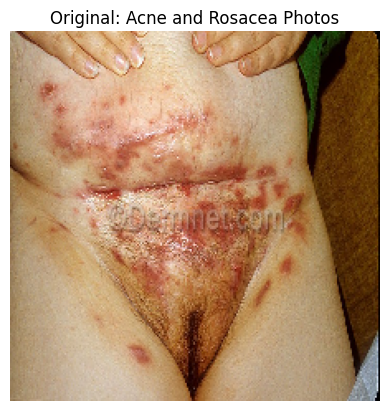

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
VGG16 Predicted: Melanoma Skin Cancer Nevi and Moles
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
ResNet50 Predicted: Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
InceptionV3 Predicted: Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions


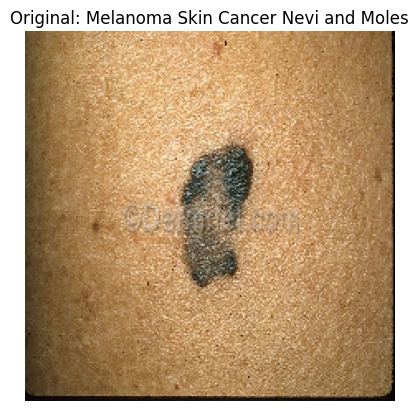

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
VGG16 Predicted: Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
ResNet50 Predicted: Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
InceptionV3 Predicted: Melanoma Skin Cancer Nevi and Moles


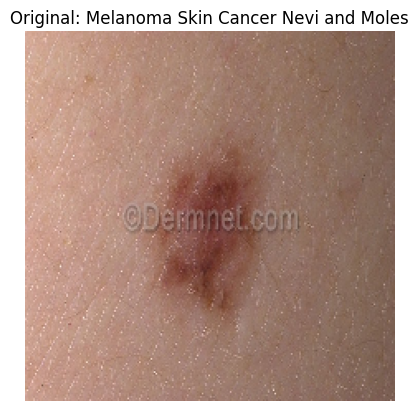

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
VGG16 Predicted: Melanoma Skin Cancer Nevi and Moles
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
ResNet50 Predicted: Acne and Rosacea Photos
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
InceptionV3 Predicted: Acne and Rosacea Photos


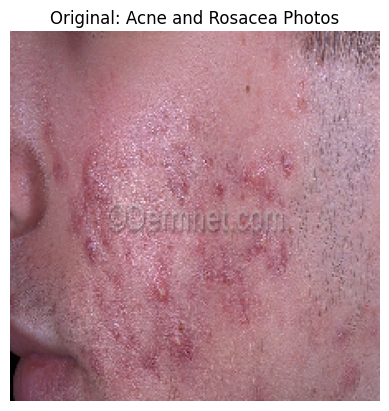

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
VGG16 Predicted: Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
ResNet50 Predicted: Acne and Rosacea Photos
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
InceptionV3 Predicted: Melanoma Skin Cancer Nevi and Moles


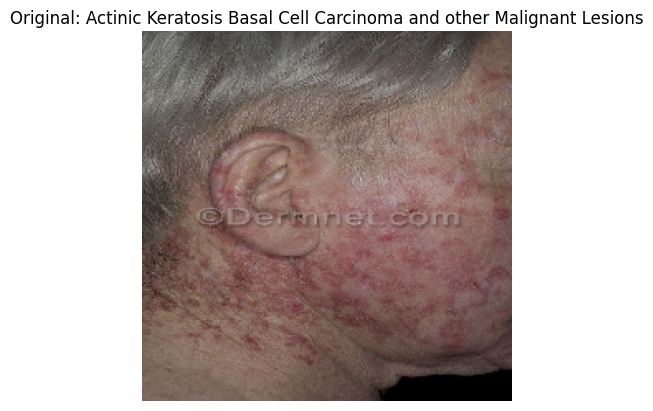

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
VGG16 Predicted: Melanoma Skin Cancer Nevi and Moles
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
ResNet50 Predicted: Acne and Rosacea Photos
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
InceptionV3 Predicted: Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions


In [7]:

import random
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Get a few test images
test_image_paths = [os.path.join(test_dir, folder, fname) 
                    for folder in os.listdir(test_dir)
                    for fname in os.listdir(os.path.join(test_dir, folder))]
random_images = random.sample(test_image_paths, 5)

for img_path in random_images:
    img = load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Original: {os.path.basename(os.path.dirname(img_path))}")
    plt.show()
    
    for name, base_model in models.items():
        model = build_model(base_model)
        pred = np.argmax(model.predict(img_array), axis=1)[0]
        pred_label = list(test_generator.class_indices.keys())[pred]
        print(f"{name} Predicted: {pred_label}")

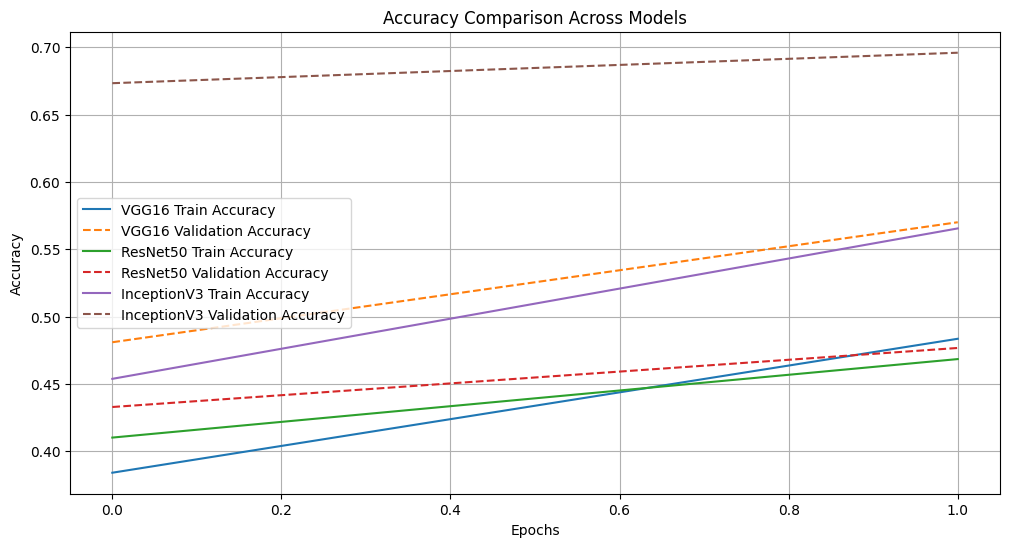

'plt.figure(figsize=(12, 8))\n\nfor name, result in results.items():\n    plt.plot(result["history"]["accuracy"], label=f"{name} Train Accuracy")\n    plt.plot(result["history"]["val_accuracy"], label=f"{name} Validation Accuracy", linestyle="--")\n\nplt.title("Training and Validation Accuracy Comparison", fontsize=16)\nplt.xlabel("Epochs", fontsize=14)\nplt.ylabel("Accuracy", fontsize=14)\nplt.legend(fontsize=12)\nplt.grid(alpha=0.5)\nplt.tight_layout()\nplt.show()'

In [8]:

# Plot training and validation accuracy comparison
plt.figure(figsize=(12, 6))
for name, result in results.items():
    plt.plot(result["history"]["accuracy"], label=f"{name} Train Accuracy")
    plt.plot(result["history"]["val_accuracy"], label=f"{name} Validation Accuracy", linestyle="--")
plt.title("Accuracy Comparison Across Models")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show() 

# Plot training and validation accuracy for all models in one frame
'''plt.figure(figsize=(12, 8))

for name, result in results.items():
    plt.plot(result["history"]["accuracy"], label=f"{name} Train Accuracy")
    plt.plot(result["history"]["val_accuracy"], label=f"{name} Validation Accuracy", linestyle="--")

plt.title("Training and Validation Accuracy Comparison", fontsize=16)
plt.xlabel("Epochs", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()'''



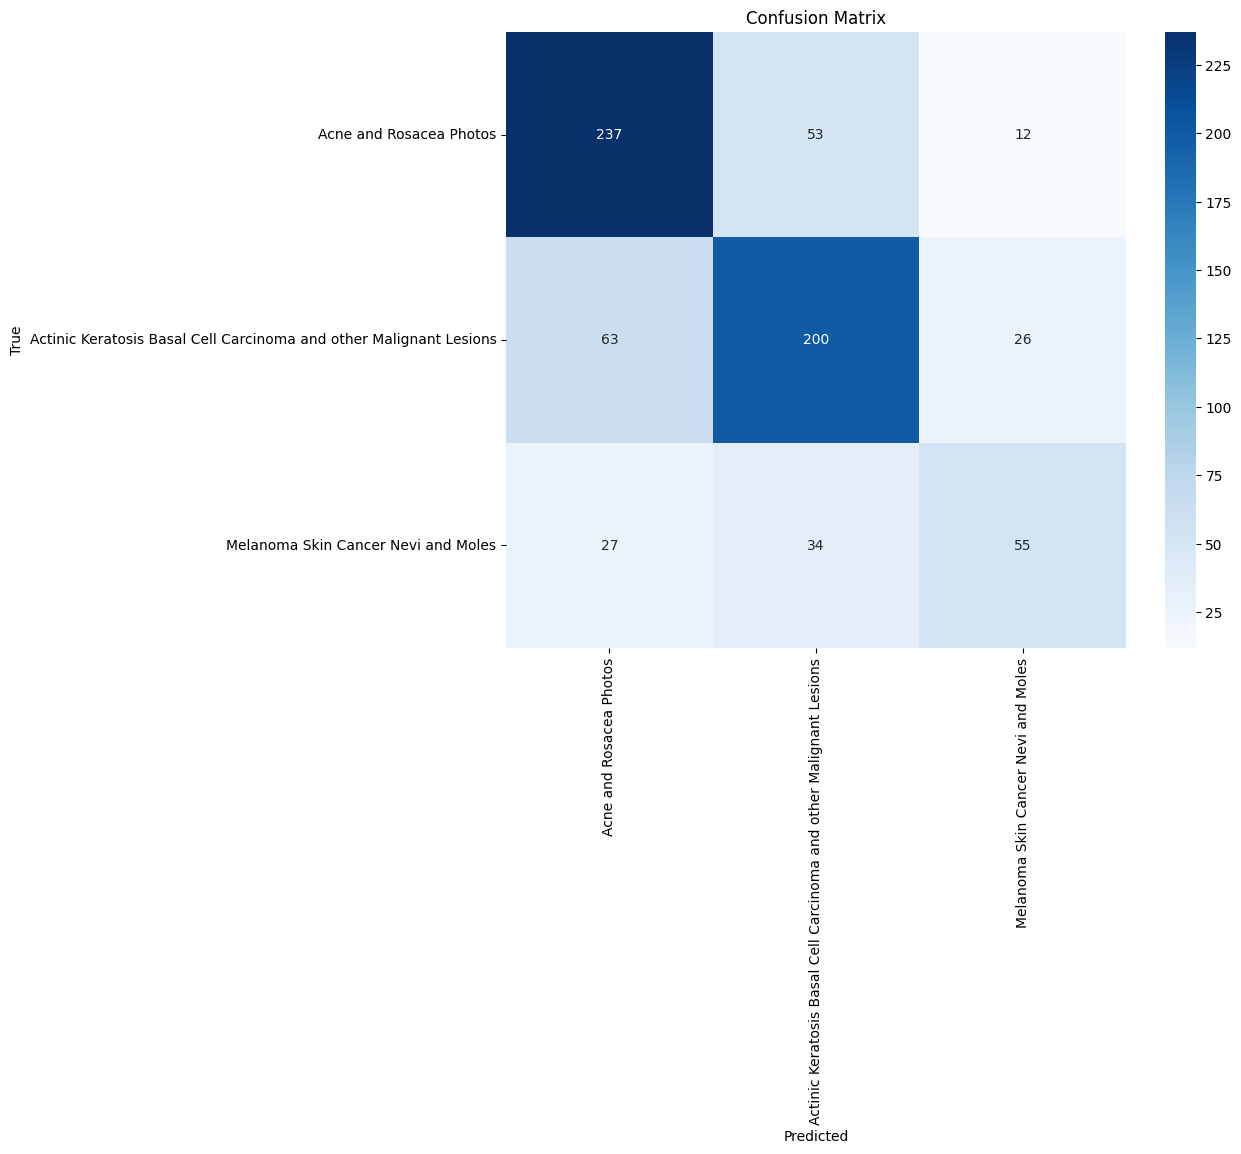

In [9]:
# Plot confusion matrix for the last model
conf_matrix = confusion_matrix(true_labels, predictions_by_model["InceptionV3"])
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()